# Week 6: Final Evaluation and Report Outputs

This notebook uses the Week 5 experimental outputs to generate final report-ready tables and figures.

The main purpose of this Week 6 notebook is to:

1. Load the Week 5 CSV results.
2. Create final summary tables for the report.
3. Generate a dedicated scalability analysis figure for Section 5.5.
4. Save report-ready CSV files and PNG figures.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("week6_outputs", exist_ok=True)
os.makedirs("week6_outputs/report_figures", exist_ok=True)
os.makedirs("week6_outputs/report_tables", exist_ok=True)

print("Week 6 setup complete.")

Week 6 setup complete.


In [2]:
from google.colab import files

uploaded = files.upload()

Saving week5_attention_summary.csv to week5_attention_summary.csv
Saving week5_attention_results.csv to week5_attention_results.csv


In [3]:
results_df = pd.read_csv("week5_attention_results.csv")
summary_df = pd.read_csv("week5_attention_summary.csv")

print("Week 5 results loaded.")
print("results_df shape:", results_df.shape)
print("summary_df shape:", summary_df.shape)

results_df.head()

Week 5 results loaded.
results_df shape: (64, 7)
summary_df shape: (4, 6)


,implementation,batch_size,seq_len,tile_size,runtime_ms,peak_memory_mb,max_abs_error
0,baseline,1,128,NaN,0.175711,9.2500,0.0
1,dsl_baseline,1,128,NaN,0.178399,9.2500,0.0
2,tiled,1,128,64.0,0.346229,9.3125,0.0
3,streaming,1,128,64.0,0.569511,9.3125,0.0
4,tiled,1,128,128.0,0.246769,9.7500,0.0


In [4]:
results_df["tile_label"] = results_df["tile_size"].apply(
    lambda x: "none" if pd.isna(x) else f"tile={int(x)}"
)

results_df["plot_label"] = results_df.apply(
    lambda row: row["implementation"]
    if row["tile_label"] == "none"
    else f"{row['implementation']}, {row['tile_label']}",
    axis=1
)

results_df.head()

,implementation,batch_size,seq_len,tile_size,runtime_ms,peak_memory_mb,max_abs_error,tile_label,plot_label
0,baseline,1,128,NaN,0.175711,9.2500,0.0,none,baseline
1,dsl_baseline,1,128,NaN,0.178399,9.2500,0.0,none,dsl_baseline
2,tiled,1,128,64.0,0.346229,9.3125,0.0,tile=64,"tiled, tile=64"
3,streaming,1,128,64.0,0.569511,9.3125,0.0,tile=64,"streaming, tile=64"
4,tiled,1,128,128.0,0.246769,9.7500,0.0,tile=128,"tiled, tile=128"


## Final Runtime Comparison Table

This table summarizes runtime performance for the baseline, DSL baseline, tiled attention, and streaming attention implementations.

In [5]:
table1_runtime = results_df[
    (
        (results_df["implementation"] == "baseline")
        |
        (results_df["implementation"] == "dsl_baseline")
        |
        (
            (results_df["implementation"] == "tiled")
            &
            (results_df["tile_size"] == 128)
        )
        |
        (
            (results_df["implementation"] == "streaming")
            &
            (results_df["tile_size"] == 128)
        )
    )
    &
    (results_df["batch_size"] == 1)
].pivot_table(
    index="seq_len",
    columns="plot_label",
    values="runtime_ms"
).reset_index()

table1_runtime.to_csv(
    "week6_outputs/report_tables/table1_runtime_comparison.csv",
    index=False
)

table1_runtime

plot_label,seq_len,baseline,dsl_baseline,"streaming, tile=128","tiled, tile=128"
0,128,0.175711,0.178399,0.275217,0.246769
1,256,0.276831,0.534992,0.354856,0.326371
2,512,0.382689,0.612878,0.795938,0.811010
3,1024,1.189107,1.186910,2.142589,2.120819


## Final Peak Memory Comparison Table

This table summarizes peak GPU memory usage for the baseline, tiled, and streaming implementations.

In [6]:
table2_memory = results_df[
    (
        (results_df["implementation"] == "baseline")
        |
        (
            (results_df["implementation"] == "tiled")
            &
            (results_df["tile_size"] == 128)
        )
        |
        (
            (results_df["implementation"] == "streaming")
            &
            (results_df["tile_size"] == 128)
        )
    )
    &
    (results_df["batch_size"] == 1)
].pivot_table(
    index="seq_len",
    columns="plot_label",
    values="peak_memory_mb"
).reset_index()

table2_memory.to_csv(
    "week6_outputs/report_tables/table2_peak_memory_comparison.csv",
    index=False
)

table2_memory

plot_label,seq_len,baseline,"streaming, tile=128","tiled, tile=128"
0,128,9.250,9.75,9.75
1,256,11.750,11.25,12.00
2,512,19.375,14.25,16.00
3,1024,46.625,20.25,24.00


## Final Implementation Summary Table

This table summarizes average runtime, maximum runtime, average peak memory, maximum peak memory, and correctness error across implementations.

In [7]:
table3_summary = results_df.groupby(
    "implementation"
).agg(
    avg_runtime_ms=("runtime_ms", "mean"),
    max_runtime_ms=("runtime_ms", "max"),
    avg_peak_memory_mb=("peak_memory_mb", "mean"),
    max_peak_memory_mb=("peak_memory_mb", "max"),
    max_correctness_error=("max_abs_error", "max")
).reset_index()

table3_summary.to_csv(
    "week6_outputs/report_tables/table3_implementation_summary.csv",
    index=False
)

table3_summary

,implementation,avg_runtime_ms,max_runtime_ms,avg_peak_memory_mb,max_peak_memory_mb,max_correctness_error
0,baseline,0.612461,1.803124,28.937500,85.125,0.0
1,dsl_baseline,0.725204,1.802167,28.937500,85.125,0.0
2,streaming,1.256432,5.653193,17.088542,40.625,0.0
3,tiled,1.237103,5.544240,19.567708,55.625,0.0


## Memory Reduction Analysis

This table calculates memory savings for tiled and streaming attention relative to the baseline implementation.

In [8]:
memory_reduction_df = table2_memory.copy()

baseline_col = "baseline"
tiled_col = "tiled, tile=128"
streaming_col = "streaming, tile=128"

memory_reduction_df["tiled_memory_reduction_percent"] = (
    (memory_reduction_df[baseline_col] - memory_reduction_df[tiled_col])
    / memory_reduction_df[baseline_col]
) * 100

memory_reduction_df["streaming_memory_reduction_percent"] = (
    (memory_reduction_df[baseline_col] - memory_reduction_df[streaming_col])
    / memory_reduction_df[baseline_col]
) * 100

memory_reduction_df["tiled_reduction_factor"] = (
    memory_reduction_df[baseline_col] / memory_reduction_df[tiled_col]
)

memory_reduction_df["streaming_reduction_factor"] = (
    memory_reduction_df[baseline_col] / memory_reduction_df[streaming_col]
)

memory_reduction_df.to_csv(
    "week6_outputs/week6_memory_reduction_analysis.csv",
    index=False
)

memory_reduction_df

plot_label,seq_len,baseline,"streaming, tile=128","tiled, tile=128",tiled_memory_reduction_percent,streaming_memory_reduction_percent,tiled_reduction_factor,streaming_reduction_factor
0,128,9.250,9.75,9.75,-5.405405,-5.405405,0.948718,0.948718
1,256,11.750,11.25,12.00,-2.127660,4.255319,0.979167,1.044444
2,512,19.375,14.25,16.00,17.419355,26.451613,1.210938,1.359649
3,1024,46.625,20.25,24.00,48.525469,56.568365,1.942708,2.302469


## Figure 6: Scalability Analysis Across Sequence Lengths

This figure is designed for Section 5.5 of the final report. It emphasizes how peak memory usage scales as sequence length increases.

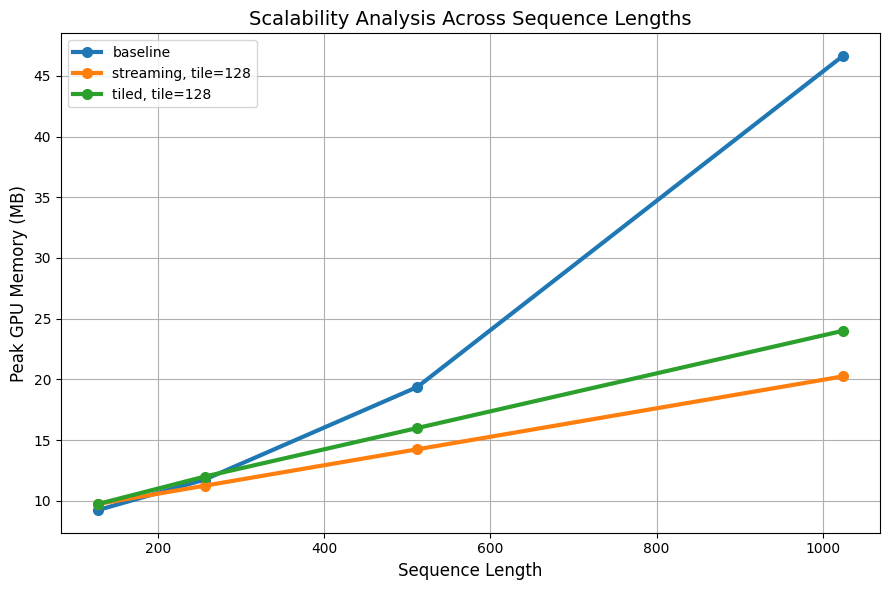

In [9]:
figure6_df = results_df[
    (
        (results_df["implementation"] == "baseline")
        |
        (
            (results_df["implementation"] == "tiled")
            &
            (results_df["tile_size"] == 128)
        )
        |
        (
            (results_df["implementation"] == "streaming")
            &
            (results_df["tile_size"] == 128)
        )
    )
    &
    (results_df["batch_size"] == 1)
]

plt.figure(figsize=(9, 6))

for label, group in figure6_df.groupby("plot_label"):

    group = group.sort_values("seq_len")

    plt.plot(
        group["seq_len"],
        group["peak_memory_mb"],
        marker="o",
        linewidth=3,
        markersize=7,
        label=label
    )

plt.xlabel("Sequence Length", fontsize=12)
plt.ylabel("Peak GPU Memory (MB)", fontsize=12)
plt.title("Scalability Analysis Across Sequence Lengths", fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "week6_outputs/report_figures/figure6_scalability_analysis.png",
    dpi=300
)

plt.show()

## Figure 7: Memory Reduction Percentage

This optional figure can be used near the end of Section 5 or in Section 5.5/5.6 if an additional summary visualization is needed.

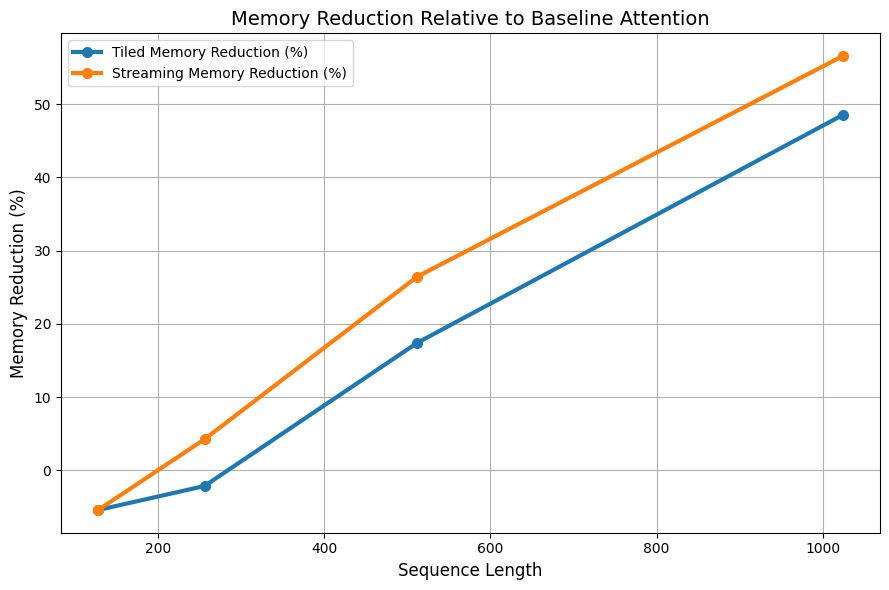

In [10]:
plt.figure(figsize=(9, 6))

plt.plot(
    memory_reduction_df["seq_len"],
    memory_reduction_df["tiled_memory_reduction_percent"],
    marker="o",
    linewidth=3,
    markersize=7,
    label="Tiled Memory Reduction (%)"
)

plt.plot(
    memory_reduction_df["seq_len"],
    memory_reduction_df["streaming_memory_reduction_percent"],
    marker="o",
    linewidth=3,
    markersize=7,
    label="Streaming Memory Reduction (%)"
)

plt.xlabel("Sequence Length", fontsize=12)
plt.ylabel("Memory Reduction (%)", fontsize=12)
plt.title("Memory Reduction Relative to Baseline Attention", fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "week6_outputs/report_figures/figure7_memory_reduction_percent.png",
    dpi=300
)

plt.show()

## Final Report Results Summary Numbers

This cell prints key values that can be used in the Results and Discussion sections of the final report.

In [11]:
max_baseline_memory = table3_summary.loc[
    table3_summary["implementation"] == "baseline",
    "max_peak_memory_mb"
].iloc[0]

max_tiled_memory = table3_summary.loc[
    table3_summary["implementation"] == "tiled",
    "max_peak_memory_mb"
].iloc[0]

max_streaming_memory = table3_summary.loc[
    table3_summary["implementation"] == "streaming",
    "max_peak_memory_mb"
].iloc[0]

avg_baseline_runtime = table3_summary.loc[
    table3_summary["implementation"] == "baseline",
    "avg_runtime_ms"
].iloc[0]

avg_dsl_runtime = table3_summary.loc[
    table3_summary["implementation"] == "dsl_baseline",
    "avg_runtime_ms"
].iloc[0]

avg_tiled_runtime = table3_summary.loc[
    table3_summary["implementation"] == "tiled",
    "avg_runtime_ms"
].iloc[0]

avg_streaming_runtime = table3_summary.loc[
    table3_summary["implementation"] == "streaming",
    "avg_runtime_ms"
].iloc[0]

max_correctness_error = table3_summary["max_correctness_error"].max()

print("Final Report Summary Numbers")
print("--------------------------------")
print(f"Maximum baseline memory: {max_baseline_memory:.2f} MB")
print(f"Maximum tiled memory: {max_tiled_memory:.2f} MB")
print(f"Maximum streaming memory: {max_streaming_memory:.2f} MB")
print()
print(f"Average baseline runtime: {avg_baseline_runtime:.4f} ms")
print(f"Average DSL baseline runtime: {avg_dsl_runtime:.4f} ms")
print(f"Average tiled runtime: {avg_tiled_runtime:.4f} ms")
print(f"Average streaming runtime: {avg_streaming_runtime:.4f} ms")
print()
print(f"Maximum correctness error: {max_correctness_error:.8f}")

Final Report Summary Numbers
--------------------------------
Maximum baseline memory: 85.12 MB
Maximum tiled memory: 55.62 MB
Maximum streaming memory: 40.62 MB

Average baseline runtime: 0.6125 ms
Average DSL baseline runtime: 0.7252 ms
Average tiled runtime: 1.2371 ms
Average streaming runtime: 1.2564 ms

Maximum correctness error: 0.00000000


## Save Final Week 6 Output Tables

In [12]:
table1_runtime.to_csv(
    "week6_outputs/week6_final_runtime_table.csv",
    index=False
)

table2_memory.to_csv(
    "week6_outputs/week6_final_memory_table.csv",
    index=False
)

table3_summary.to_csv(
    "week6_outputs/week6_final_results_table.csv",
    index=False
)

memory_reduction_df.to_csv(
    "week6_outputs/week6_memory_reduction_analysis.csv",
    index=False
)

print("Saved final Week 6 tables:")
print("week6_outputs/week6_final_runtime_table.csv")
print("week6_outputs/week6_final_memory_table.csv")
print("week6_outputs/week6_final_results_table.csv")
print("week6_outputs/week6_memory_reduction_analysis.csv")

Saved final Week 6 tables:
week6_outputs/week6_final_runtime_table.csv
week6_outputs/week6_final_memory_table.csv
week6_outputs/week6_final_results_table.csv
week6_outputs/week6_memory_reduction_analysis.csv


## Download Final Week 6 Outputs

In [13]:
files.download("week6_outputs/week6_final_runtime_table.csv")
files.download("week6_outputs/week6_final_memory_table.csv")
files.download("week6_outputs/week6_final_results_table.csv")
files.download("week6_outputs/week6_memory_reduction_analysis.csv")

files.download("week6_outputs/report_tables/table1_runtime_comparison.csv")
files.download("week6_outputs/report_tables/table2_peak_memory_comparison.csv")
files.download("week6_outputs/report_tables/table3_implementation_summary.csv")

files.download("week6_outputs/report_figures/figure6_scalability_analysis.png")
files.download("week6_outputs/report_figures/figure7_memory_reduction_percent.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Week 6 Summary

This Week 6 notebook used the updated Week 5 experimental results to generate final report-ready tables and figures.

The notebook produced:

1. Final runtime comparison table  
2. Final peak memory comparison table  
3. Final implementation summary table  
4. Memory reduction analysis table  
5. Figure 6: Scalability Analysis Across Sequence Lengths  
6. Figure 7: Memory Reduction Relative to Baseline Attention  

Figure 6 is intended for Section 5.5 of the final report because it directly supports the scalability discussion. Figure 7 is optional but can be used as a final visual summary of memory reduction behavior.